# Project 2: Transformers

This project is part of the NLP module held in the spring of 2026. Three transformer models are compared, answering physical common sense tasks with the PIQA dataset. 

- **Randomly Initialized Transformer** 
- **Pretrained Transformer** not pretrained or finetuned on PIQA dataset
- **LLM (1B+ Parameters)** same hyperparameters

**Weights & Biases**  
All experimental runs are logged and published in the [W&B report](https://api.wandb.ai/links/sacha-vogel-hochschule-luzern/nv22fryc).

**Dataset**  
"PIQA: Reasoning about Physical Commonsense in Natural Language" — a binary choice task
where a model selects the more physically plausible solution to a given goal.  
Source: [https://arxiv.org/abs/1911.11641](https://arxiv.org/abs/1911.11641)

**Tools** 
- Course Materials
- Documentations (mostly of imported dependencies)
    - apxml
    - NLTK
    - PyTorch
    - skikit-learn
- Claude AI for the following tasks:
    - Helping formulate and clarify reasoning
    - General coding assistance
- Regex101
- Huggingface

**Notebook structure**
1. Introduction
2. Setup
3. Preprocessing
4. Model
5. Training
6. Evaluation
7. Interpretation


## Setup

Two variables are introduced to make skip transformer model training runs or the LLM inference ensuring a performant notebook execution. 

In [1]:
SKIP_TRAINING = True
SKIP_LLM_INFERENCE = False

In [2]:
!pip install \
    datasets==4.8.4 \
    numpy==2.4.4 \
    datetime==6.0.0 \
    transformers==5.6.2 \
    torch==2.10.0 \
    scikit-learn==1.8.0 \
    matplotlib==3.10.9 \
    wandb==0.25.1

In [3]:
from datasets import load_dataset
from datetime import datetime
from transformers import AutoTokenizer, BertConfig, BertModel, AutoModelForCausalLM
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
import matplotlib.pyplot as plt
import torch.nn as nn
import numpy as np
import wandb
import re
import torch

In [4]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
generator = torch.Generator()
generator.manual_seed(SEED)

In [5]:
TS = datetime.now().strftime("%Y%m%d_%H%M%S")

In [6]:
wandb_project = "nlp-project2-piqa"

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Preprocessing

### Train / Validation / Test Splits

Splits follow the course specification and was done equally in project 1. Since loading via dataset scripts is no longer supported on HuggingFace, the parquet branch is used directly.

Train: 15'113 examples (training only)
Validation: 1'000 examples
Test: 1'838 examples (final evaluation — not touched until the end)

In [8]:
train_split = load_dataset("ybisk/piqa", split="train[:-1000]", revision='refs/convert/parquet')
valid_split = load_dataset("ybisk/piqa", split="train[-1000:]", revision='refs/convert/parquet')
test_split = load_dataset("ybisk/piqa", split="validation", revision='refs/convert/parquet')

### Feature Selection

The following features are represented in the dataset, those are the same as in project 1. 

```
COL_GOAL = 'goal' # "How do I ready a guinea pig cage for it's new occupants?"
COL_SOL1 = 'sol1' # "Provide the guinea pig with a cage full of a few inches of bedding made of ripped paper strips, you will also need to supply it with a water bottle and a food dish."
COL_SOL2 = 'sol2' # "Provide the guinea pig with a cage full of a few inches of bedding made of ripped jeans material, you will also need to supply it with a water bottle and a food dish."
COL_LABEL = 'label' # 0 (0 -> 'sol1' / 1 -> 'sol2')
```


In [9]:
COL_GOAL = 'goal'
COL_SOL1 = 'sol1'
COL_SOL2 = 'sol2'
COL_LABEL = 'label'

### Filter HTML Elements

In the first project no HTML elements were found in the data set. To supply a thorough notebook the same search for HTML elements was performed. 

The regex was again verified with https://regex101.com.


In [10]:
# regex source: https://apxml.com/courses/nlp-fundamentals/chapter-1-nlp-text-processing-techniques/handling-text-noise
# verified with: https://regex101.com
regex_pattern = re.compile(r'<[^>]+>', re.IGNORECASE)
html_elements = 0

for split in [train_split, valid_split, test_split]:
    html_elements += len(split.filter(lambda row: regex_pattern.search(row[COL_GOAL])))
    html_elements += len(split.filter(lambda row: regex_pattern.search(row[COL_SOL1])))
    html_elements += len(split.filter(lambda row: regex_pattern.search(row[COL_SOL2])))

print(f"Number of HTML elements found: {html_elements}")

Number of HTML elements found: 0


### Input Format

The `bert-base-uncased` tokenizer is used. This matches the pretrained transformer exactly. 
This is a WordPiece tokenizer which does not produce the `<UNK>` token, becuase it splits any word into known subword pieces. 
The **uncased** variant lowers text before tokenization. That reduces vocabulary size without loosing meaningful information for the PIQA physical commonsense task. 

Stemming, lemmatization, stopword removal, and punctuation removal are all omitted. Unlike project 1 where these steps were applied manually before embedding lookup, the WordPiece tokenizer handles subword decomposition internally and expects raw, minimally processed text. Applying stemming or punctuation removal beforehand would corrupt the token boundaries that WordPiece relies on and could produce tokens that do not exist in the vocabulary.

The goal and the corresponding solution are passed together to the tokenizer as a sentence pair. This produces a single sequence with a [CLS] token at the start, a [SEP] token between goal and solution, and a final [SEP] at the end. 

**Tokenized Input**
```
['[CLS]', 'when', 'boiling', 'butter', ',', 'when', 'it', "'", 's', 'ready', ',', 'you', 'can', '[SEP]', 'pour', 'it', 'onto', 'a', 'plate', '[SEP]']
```

Those following fields are generated by the tokenizer for each solution:

The **token_type_ids** field marks which tokens belong to the goal and which to the solution, giving the model an explicit structural signal about the two roles.
The **attention_mask** marks which tokens are relevant. 
The **input_ids** represents the token ids as a list. 

These fields for each solution and the label are merged into the final input format:

**Final Input Format**
```
{
  "label": 1,
  "input1_attention_mask":   [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  "input1_input_ids":        [101, 2043, 16018, 12136, 1010, 2043, 2009, 1005, 1055, 3201, 1010, 2017, 2064, 102, 10364, 2009, 3031, 1037, 5127, 102],
  "input1_token_type_ids":   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
  "input2_attention_mask":   [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  "input2_input_ids":        [101, 2043, 16018, 12136, 1010, 2043, 2009, 1005, 1055, 3201, 1010, 2017, 2064, 102, 10364, 2009, 2046, 1037, 15723, 102],
  "input2_token_type_ids":   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
}
```


In [11]:
# MAX_INPUT_LENGTH = 512 # value found by analysis further down
MAX_INPUT_LENGTH = 126 # value found by analysis further down (99th percentile)

COL_INPUT1 = 'input1'
COL_INPUT2 = 'input2'

ATTENTION_MASK = 'attention_mask'
INPUT_IDS = 'input_ids'
TOKEN_TYPE_IDS = 'token_type_ids'

COL_INPUT1_ATTENTION_MASK = f"{COL_INPUT1}_{ATTENTION_MASK}"
COL_INPUT1_INPUT_IDS = f"{COL_INPUT1}_{INPUT_IDS}"
COL_INPUT1_TOKEN_TYPE_IDS = f"{COL_INPUT1}_{TOKEN_TYPE_IDS}"
COL_INPUT2_ATTENTION_MASK = f"{COL_INPUT2}_{ATTENTION_MASK}"
COL_INPUT2_INPUT_IDS = f"{COL_INPUT2}_{INPUT_IDS}"
COL_INPUT2_TOKEN_TYPE_IDS  = f"{COL_INPUT2}_{TOKEN_TYPE_IDS}"

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def preprocess_row(row):
    tokenized1 = tokenizer(row[COL_GOAL], row[COL_SOL1], truncation=True, max_length=MAX_INPUT_LENGTH)
    tokenized2 = tokenizer(row[COL_GOAL], row[COL_SOL2], truncation=True, max_length=MAX_INPUT_LENGTH)
    return {
        COL_LABEL: row[COL_LABEL],
        COL_INPUT1_ATTENTION_MASK: tokenized1[ATTENTION_MASK],
        COL_INPUT1_INPUT_IDS: tokenized1[INPUT_IDS],
        COL_INPUT1_TOKEN_TYPE_IDS: tokenized1[TOKEN_TYPE_IDS],
        COL_INPUT2_ATTENTION_MASK: tokenized2[ATTENTION_MASK],
        COL_INPUT2_INPUT_IDS: tokenized2[INPUT_IDS],
        COL_INPUT2_TOKEN_TYPE_IDS: tokenized2[TOKEN_TYPE_IDS],
    }

train_processed = train_split.map(preprocess_row, remove_columns=train_split.column_names, batched=False)
valid_processed = valid_split.map(preprocess_row, remove_columns=valid_split.column_names, batched=False)
test_processed = test_split.map(preprocess_row,  remove_columns=test_split.column_names, batched=False)

### Length Analysis

The approach is to pad the batches in the data loader instead of truncate all inputs to the same size. To secure performance of the tokenizer it still takes a truncation length. The analysis showed that the longest input has a length of `553`. No information would be lost taking this as an upper limit.

However, the tokenizer is limited to an input length of `512` which was used in the early attempts. This caused that the tokenizer padded all inputs to this length. Those inputs kept were kept in memory while training runs which led to `Out of Memory` problems.

The further analysis showed, that the input length of the 99th percentile was `126` only. The ensure performance in training runs and get rid of memory problems this small information loss is accepted. All the input fields are truncated to this final truncation length by the tokenizer. 

```
MAX_INPUT_LENGTH = 126
```


Max length of an input field: 126
95th percentile: 79 tokens
99th percentile: 126 tokens
Max:             126 tokens
Mean:            33 tokens


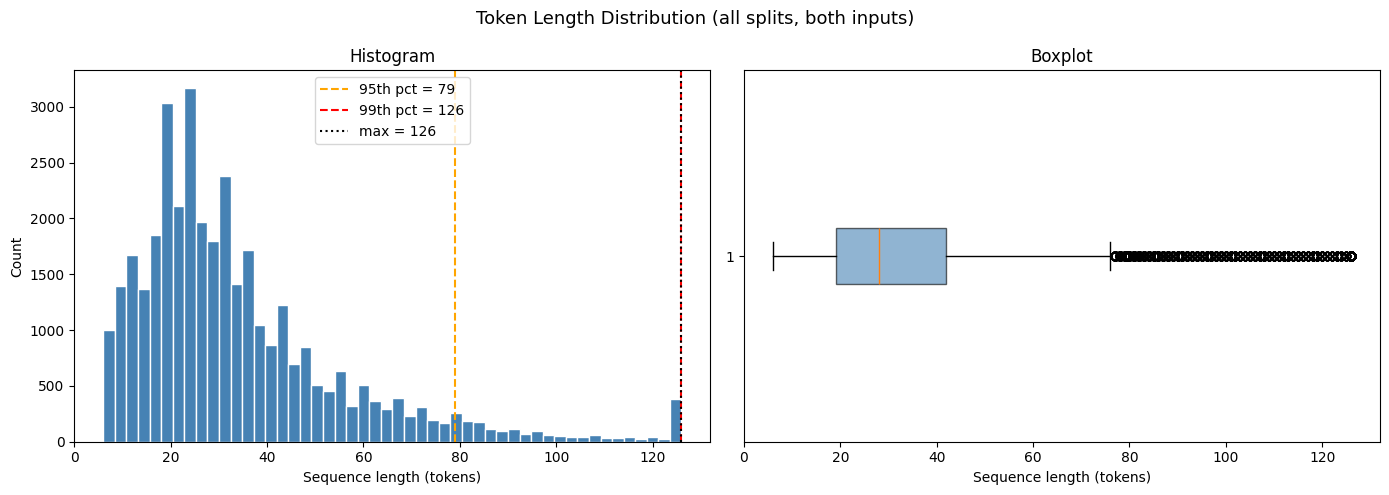

In [12]:
all_input_lengths = (
    [len(row[COL_INPUT1_ATTENTION_MASK]) for row in train_processed] +
    [len(row[COL_INPUT2_ATTENTION_MASK]) for row in train_processed] +
    [len(row[COL_INPUT1_ATTENTION_MASK]) for row in valid_processed] +
    [len(row[COL_INPUT2_ATTENTION_MASK]) for row in valid_processed] +
    [len(row[COL_INPUT1_ATTENTION_MASK]) for row in test_processed] +
    [len(row[COL_INPUT2_ATTENTION_MASK]) for row in test_processed]
)

print(f"Max length of an input field: {np.max(all_input_lengths)}") 

def compute_length_stats(lengths):
    return {
        "p95":  int(np.percentile(lengths, 95)),
        "p99":  int(np.percentile(lengths, 99)),
        "max":  int(np.max(lengths)),
        "mean": int(np.mean(lengths)),
    }

def plot_length_histogram(ax, lengths, stats):
    ax.hist(lengths, bins=50, color="steelblue", edgecolor="white")
    ax.axvline(stats["p95"], color="orange", linestyle="--", label=f"95th pct = {stats['p95']}")
    ax.axvline(stats["p99"], color="red",    linestyle="--", label=f"99th pct = {stats['p99']}")
    ax.axvline(stats["max"], color="black",  linestyle=":",  label=f"max = {stats['max']}")
    ax.set_xlabel("Sequence length (tokens)")
    ax.set_ylabel("Count")
    ax.set_title("Histogram")
    ax.legend()

def plot_length_boxplot(ax, lengths):
    ax.boxplot(lengths, vert=False, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.6))
    ax.set_xlabel("Sequence length (tokens)")
    ax.set_title("Boxplot")

def plot_length_distribution(lengths, title="Token Length Distribution"):
    stats = compute_length_stats(lengths)
    print(f"95th percentile: {stats['p95']} tokens")
    print(f"99th percentile: {stats['p99']} tokens")
    print(f"Max:             {stats['max']} tokens")
    print(f"Mean:            {stats['mean']} tokens")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13)
    plot_length_histogram(ax1, lengths, stats)
    plot_length_boxplot(ax2, lengths)
    plt.tight_layout()
    plt.show()


# Usage
plot_length_distribution(all_input_lengths, title="Token Length Distribution (all splits, both inputs)")

### Data Loader

A batch size of `32` was chosen. This size has been deliberately chosen to be on the small side to comfortably fit the GPU memory given the input lengths. 

Padding is applied dynamically per batch in the `collate_fn` rather than globally. Each batch is padded to the length of its longest sequence, not to `MAX_INPUT_LENGTH`. This keeps shorter batches compact and reduces unnecessary computation, which was especially important given the `Out of Memory` issues encountered with static padding to `512`.

The training loader is shuffled with the seeded generator to ensure reproducible but randomized batch order across epochs. Validation and test loaders are not shuffled, as order does not affect evaluation.


In [13]:
BATCH_SIZE = 32

class PiqaDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data[idx]
        return {
            COL_INPUT1_INPUT_IDS: torch.tensor(row[COL_INPUT1_INPUT_IDS]),
            COL_INPUT1_ATTENTION_MASK: torch.tensor(row[COL_INPUT1_ATTENTION_MASK]),
            COL_INPUT1_TOKEN_TYPE_IDS: torch.tensor(row[COL_INPUT1_TOKEN_TYPE_IDS]),
            COL_INPUT2_INPUT_IDS: torch.tensor(row[COL_INPUT2_INPUT_IDS]),
            COL_INPUT2_ATTENTION_MASK: torch.tensor(row[COL_INPUT2_ATTENTION_MASK]),
            COL_INPUT2_TOKEN_TYPE_IDS: torch.tensor(row[COL_INPUT2_TOKEN_TYPE_IDS]),
            COL_LABEL: torch.tensor(row[COL_LABEL]),
        }
    
def pad_sequence(sequences):
    max_length_in_batch = max(len(s) for s in sequences)
    return torch.stack([
        torch.nn.functional.pad(s, (0, max_length_in_batch - len(s))) for s in sequences
    ])

def collate_fn(batch):
    input1_ids = pad_sequence([item[COL_INPUT1_INPUT_IDS] for item in batch])
    input1_attention_mask = pad_sequence([item[COL_INPUT1_ATTENTION_MASK] for item in batch])
    input1_token_type_ids = pad_sequence([item[COL_INPUT1_TOKEN_TYPE_IDS] for item in batch])
    input2_ids = pad_sequence([item[COL_INPUT2_INPUT_IDS] for item in batch])
    input2_attention_mask = pad_sequence([item[COL_INPUT2_ATTENTION_MASK] for item in batch])
    input2_token_type_ids = pad_sequence([item[COL_INPUT2_TOKEN_TYPE_IDS] for item in batch])
    labels = torch.tensor([item[COL_LABEL] for item in batch], dtype=torch.long)

    return (
        input1_ids, 
        input1_attention_mask, 
        input1_token_type_ids,
        input2_ids, 
        input2_attention_mask, 
        input2_token_type_ids,
        labels
    )

# The training set has to be shuffled to ensure random order in training which makes training more stable.  
train_loader = DataLoader(PiqaDataset(train_processed), batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True, generator=generator, pin_memory=True)
# Test and Validation should not be shuffled to ensure reproducibility and consistency of the model.
valid_loader = DataLoader(PiqaDataset(valid_processed), batch_size=BATCH_SIZE, collate_fn=collate_fn, pin_memory=True)
test_loader = DataLoader(PiqaDataset(test_processed), batch_size=BATCH_SIZE, collate_fn=collate_fn)

## Model

### Bert Classifier

The same `BertTransformerClassifier` architecture is used for both the randomly initialized and the pretrained transformer, as required by the project specification. This ensures that any performance difference between the two is attributable to the pretrained weights alone, not to architectural differences.

`bert-base-uncased` is used as the pretrained checkpoint which matches the tokenizer exactly. 
It was pretrained on BooksCorpus and English Wikipedia it carries broad everyday English language understanding, which transfers well to PIQA since the task requires understanding physical descriptions of goals and actions rather than domain-specific knowledge.
This variant with 110M parameters fits comfortably within the available GPU memory and training time constraints.

Source: [https://huggingface.co/google-bert/bert-base-uncased](https://huggingface.co/google-bert/bert-base-uncased)


#### Classifier
Each input is encoded independently into a 768-dimensional `[CLS]` vector. The two vectors are concatenated to a 1536-dimensional combined representation and passed through:

```
Linear(1536, 768) → ReLU → Dropout(p) → Linear(768, 2)
```

The hidden dimension is halved from the input to compress the representation before the final classification. ReLU introduces non-linearity.

#### Output
The classifier outputs two logits, one per class. The predicted label is the argmax, which is compared directly to the dataset label (`0` for sol1, `1` for sol2).

In [14]:
class BertTransformerClassifier(nn.Module):

    def __init__(self, bert: BertModel, dropout_p: float):
        super().__init__()
        self.bert = bert
        hidden_size = bert.config.hidden_size
        input_hidden_dim = 2 * hidden_size
        classifier_hidden_dim = input_hidden_dim // 2

        self.classifier = nn.Sequential(
            nn.Linear(input_hidden_dim, classifier_hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(classifier_hidden_dim, 2),
        )

    def encode(self, input_ids, attention_mask, token_type_ids):
        output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        # output: (B, L, 768)
        # B: for the whole batch size
        # L: length of input (nr of tokens)
        # 768 dim vector which is a summary of the whole input but biased by the current token -> [CLS] does not influence the summary -> all tokens are weighed based on the importance of the information they carry -> we can use this dim only
        cls_vector = output.last_hidden_state[:, 0, :]
        return cls_vector
    
    def forward(self, 
                input1_ids, input1_attention_mask, input1_token_type_ids, 
                input2_ids, input2_attention_mask, input2_token_type_ids):
        cls1 = self.encode(input1_ids, input1_attention_mask, input1_token_type_ids)
        cls2 = self.encode(input2_ids, input2_attention_mask, input2_token_type_ids)
        # cls dim: 768
        # combined dim: 2 * 768
        combined = torch.cat([cls1, cls2], dim=-1)
        logits = self.classifier(combined)
        return logits

### Randomly Initialized Transformer

`BertConfig()` with no arguments produces the default `bert-base-uncased` configuration:

- **12 layers**
- **12 attention heads**
- **768 hidden size**

Passing this to BertModel gives a randomly initialized transformer with identical architecture to the pretrained model.


In [15]:
def get_randomly_initialized_transformer():
    # use default config to match pretrained transformer
    # defaults described here: https://huggingface.co/docs/transformers/model_doc/bert#transformers.BertConfig
    bert_config_random = BertConfig()
    return BertModel(bert_config_random)

### Pretrained Transformer

The architecture of the pretrained `bert-base-uncase` matches the architecture of the randomly initialized model exactly:

- **12 layers**
- **12 attention heads**
- **768 hidden size**


In [16]:
def get_pretrained_transformer(): 
    return BertModel.from_pretrained("bert-base-uncased")

### LLM (1B+ Parameters)

In this project the Qwen2.5 models are used. They were trained on large world knowledge data, therefore fitting this task perfectly. 

At first the smaller `Qwen2.5-1.5B-Instruct` with 1.5B parameters was used for inference. The accuracy on test set stuck around `0.61` even after prompt engineering. The model was operating at its maximum capacity already, optimizing the prompt had no impact on its performance. 

To improve accuracy the `Qwen2.5-3B-Instruct` with 3B parameters was applied. With the engineered prompt the accuracy improved a lot and got to overall best of `0.753`.

In [17]:
# LLM_SMALL_NAME = "Qwen/Qwen2.5-1.5B-Instruct" # initially used
LLM_NAME = "Qwen/Qwen2.5-3B-Instruct" # final LLM used

def get_llm_with_tokenizer():
    llm_tokenizer = AutoTokenizer.from_pretrained(LLM_NAME)
    llm_model = AutoModelForCausalLM.from_pretrained(LLM_NAME, dtype=torch.float16).to(device)
    return llm_model, llm_tokenizer

## Training

### Optimizer
**AdamW** is used as the optimizer as good experience was made with it in project 1. It extends Adam with decoupled weight decay, which is the recommended optimizer for fine-tuning transformer models.

### Loss Function
**CrossEntropyLoss** is used as the loss function which was already used in project 1 and worked well. It is the standard choice for classification tasks with mutually exclusive classes.

### Learning Rate Scheduler
A **OneCycleLR** scheduler is applied to the pretrained model only. 
The first three pretrained sweeps showed severe overfitting, because training accuracy climbed above `0.95` while validation accuracy plateaued around `0.60` and validation loss diverged. 
The scheduler applies a warmup phase followed by a cosine decay, which prevents the learning rate from remaining too high in later epochs and avoids destroying the pretrained weights. 

The randomly initialized transformer does not use a scheduler, as its training never progressed beyond random guessing regardless of learning rate, making a scheduler irrelevant.

### Early Stopping
`max_epochs = 30` gives both models enough room to converge. Early stopping with `patience = 5` halts training when validation accuracy does not improve for 5 consecutive epochs, preventing unnecessary computation and overfitting. 

### Checkpointing
Two checkpoints are maintained per run: a per-run checkpoint saved whenever a new best validation accuracy is reached within that run, and a global best checkpoint saved whenever a run surpasses the best validation accuracy seen across all runs of that model. The global checkpoint is loaded for final test evaluation.

### Gradient Clipping
To prevent exploding gradients, which are a risk when fine-tuning large transformer models, `nn.utils.clip_grad_norm_` with `max_norm=1.0` is applied before each optimizer step.

### Hyperparameters

The goal is to find the best hyperparameter combination for each model separately. A Bayesian sweep via W&B is run for each model, maximizing validation accuracy. Bayesian optimization is preferred over grid or random search as it uses results of previous runs to guide the next sample, making it more efficient given the limited training budget. 



#### Learning Rate
The **random transformer** sweeps over `lr = [1e-3, 1e-4, 1e-5]` since it trains from scratch and benefits from larger learning rates. 
The **pretrained transformer** sweeps over `lr = [1e-4, 1e-5]` only. Higher learning rates risk destroying the pretrained weights.

#### Weight Decay & Dropout Probability
Both models sweep over `weight_decay = [1e-3, 1e-4, 1e-5]` and `dropout_probability = [0.1, 0.3, 0.5]`.

In hindsight, it is questionable whether it is actually necessary to tune `weight_decay` and `dropout_probability`. 
Although they can improve the accuracy of the model slightly it does not justify the computational overhead caused by unnecessary sweep passes.

The **random initialized model** did not learn from the dataset regardless of the hyperparameters chosen. 

For the **pretrained model** the following combination worked best where a high dropout probability helps generalize the learned patterns. 

```
lr=1e-5
weight_decay=1e-5
dropout=0.5
```


In [18]:
MODEL1_NAME = f"random_{TS}"
MODEL2_NAME = f"pretrained_{TS}"
BEST_MODEL1_PATH = f"models/best_overall_{MODEL1_NAME}.pt"
BEST_MODEL2_PATH = f"models/best_overall_{MODEL2_NAME}.pt"
SWEEP_COUNT = 5

In [19]:
best_valid_acc_model1 = 0
best_valid_acc_model2 = 0

training_config = {
    'max_epochs': 30,
    'patience': 5,
}

# use same model architecture in model 1 and 2
def create_sweep_config(model_name, is_pretrained=False):
    lr_values = [1e-4, 1e-5] if is_pretrained else [1e-3, 1e-4, 1e-5]
    return {
        "method": "bayes",
        "metric": {"name": f"{model_name}/valid_acc", "goal": "maximize"},
        "parameters": {
            "lr":                  {"values": lr_values},
            "weight_decay":        {"values": [1e-3, 1e-4, 1e-5]},
            "dropout_probability": {"values": [0.1, 0.3, 0.5]},
        },
    }

In [20]:
if not SKIP_TRAINING:
    wandb.login()
else: 
    print("training skipped")

training skipped


In [21]:
def train_epoch(model, loader, criterion, optimizer, scheduler):
    model.train()
    total_loss, total_correct, total = 0, 0, 0

    for input1_ids, input1_mask, input1_tt, input2_ids, input2_mask, input2_tt, labels in loader:
        input1_ids, input1_mask, input1_tt = input1_ids.to(device), input1_mask.to(device), input1_tt.to(device)
        input2_ids, input2_mask, input2_tt = input2_ids.to(device), input2_mask.to(device), input2_tt.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        logits = model(input1_ids, input1_mask, input1_tt, input2_ids, input2_mask, input2_tt)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=-1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, total_correct / total

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total = 0, 0, 0

    with torch.no_grad():
        for input1_ids, input1_mask, input1_tt, input2_ids, input2_mask, input2_tt, labels in loader:
            input1_ids, input1_mask, input1_tt = input1_ids.to(device), input1_mask.to(device), input1_tt.to(device)
            input2_ids, input2_mask, input2_tt = input2_ids.to(device), input2_mask.to(device), input2_tt.to(device)
            labels = labels.to(device)
            
            logits = model(input1_ids, input1_mask, input1_tt, input2_ids, input2_mask, input2_tt)
            loss = criterion(logits, labels)

            total_loss += loss.item() * labels.size(0)
            total_correct += (logits.argmax(dim=-1) == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, total_correct / total

def save_checkpoint(model, config, valid_acc, path, label):
    torch.save({'model_state_dict': model.state_dict(), 'config': config}, path)
    print(f"New best {label} saved (valid_acc: {valid_acc:.4f})")

def train_model(model, config, model_name, wandb_run, train_loader, valid_loader, best_valid_acc_m1=None, best_valid_acc_m2=None):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config['weight_decay']
    )
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=config['lr'],
        steps_per_epoch=len(train_loader),
        epochs=config['max_epochs']
    )
    
    best_valid_acc = 0
    patience_counter = 0
    
    for epoch in range(config['max_epochs']):
        print("____________________________________")
        print(f"Epoch {epoch + 1}/{config['max_epochs']}")
        
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, scheduler)
        valid_loss, valid_acc = eval_epoch(model, valid_loader, criterion)
        
        print(f"Train loss: {train_loss:.4f} - Train acc: {train_acc:.4f} | Valid loss: {valid_loss:.4f} - Valid acc: {valid_acc:.4f}")
        
        wandb_run.log({
            f"{model_name}/epoch": epoch + 1, 
            f"{model_name}/train_loss": train_loss,
            f"{model_name}/train_acc": train_acc,
            f"{model_name}/valid_loss": valid_loss,
            f"{model_name}/valid_acc": valid_acc,
        })
        
        if valid_acc > best_valid_acc:
            best_valid_acc = valid_acc
            patience_counter = 0
            save_checkpoint(model, config, valid_acc, config['model_path'], "run model")
        
            if model_name == MODEL1_NAME and valid_acc > best_valid_acc_m1:
                best_valid_acc_m1 = valid_acc
                save_checkpoint(model, config, valid_acc, BEST_MODEL1_PATH, f"overall {model_name}")
            elif model_name == MODEL2_NAME and valid_acc > best_valid_acc_m2:
                best_valid_acc_m2 = valid_acc
                save_checkpoint(model, config, valid_acc, BEST_MODEL2_PATH, f"overall {model_name}")
                
        else:
            patience_counter += 1
            print(f"No improvement ({patience_counter}/{config['patience']})")
        
        if patience_counter >= config['patience']:
            print("Early stopping triggered")
            break
            
    return best_valid_acc_m1, best_valid_acc_m2

In [22]:
def sweep_run_model1():
    with wandb.init(project=wandb_project, config=training_config, group=f"random_{TS}") as wandb_run:
        wandb_config = wandb_run.config
        
        run_name = f"{MODEL1_NAME}_lr{wandb.config.lr}_wd{wandb.config.weight_decay}_dp{wandb.config.dropout_probability}_{wandb_run.id[:4]}"
        
        config = {
            'lr': wandb_config.lr,
            'weight_decay': wandb_config.weight_decay,
            'max_epochs': training_config['max_epochs'],
            'patience': training_config['patience'],
            'model_path': f"models/{run_name}.pt"
        }
        
        # since we are on a cuda device no extra condition needed
        model = torch.compile(BertTransformerClassifier(bert=get_randomly_initialized_transformer(), dropout_p=wandb_config.dropout_probability).to(device))

        global best_valid_acc_model1
        best_valid_acc_model1, _ = train_model(model, config, MODEL1_NAME, wandb_run, train_loader, valid_loader, best_valid_acc_m1=best_valid_acc_model1)
        
        del model
        torch.cuda.empty_cache()
        
        
if not SKIP_TRAINING:
    sweep_model1 = wandb.sweep(sweep=create_sweep_config(MODEL1_NAME), project=wandb_project)
    wandb.agent(sweep_model1, function=sweep_run_model1, count=SWEEP_COUNT)
else: 
    print("training skipped")

training skipped


The sweep run was not completed, the agent hung itself. After analsis a lr scheduler was added to improve the model. As the first three sweeps clearly showed, that the model overfits on differen lr, when using the scheduler that should be prevented. 

In [23]:
def sweep_run_model2():
    with wandb.init(project=wandb_project, config=training_config, group=f"pretrained_{TS}") as wandb_run:
        wandb_config = wandb_run.config
        
        run_name = f"{MODEL2_NAME}_lr{wandb.config.lr}_wd{wandb.config.weight_decay}_dp{wandb.config.dropout_probability}_{wandb_run.id[:4]}"
        
        config = {
            'lr': wandb_config.lr,
            'weight_decay': wandb_config.weight_decay,
            'max_epochs': training_config['max_epochs'],
            'patience': training_config['patience'],
            'model_path': f"models/{run_name}.pt"
        }
        
        model = torch.compile(BertTransformerClassifier(bert=get_pretrained_transformer(), dropout_p=wandb_config.dropout_probability).to(device))
        
        global best_valid_acc_model2
        _, best_valid_acc_model2 = train_model(model, config, MODEL2_NAME, wandb_run, train_loader, valid_loader, best_valid_acc_m2=best_valid_acc_model2)    
        
        del model
        torch.cuda.empty_cache()
        

if not SKIP_TRAINING:
    sweep_model2 = wandb.sweep(sweep=create_sweep_config(MODEL2_NAME, is_pretrained=True), project=wandb_project)
    wandb.agent(sweep_model2, function=sweep_run_model2, count=SWEEP_COUNT)
else: 
    print("training skipped")

training skipped


### LLM Prompting

#### 1. Prompt
In the first version the following prompt was given directly to the model without specifying system and user content: 

```
You are answering a physical commonsense question. Given a goal and two possible solutions, choose the more physically plausible one.

Goal: {goal}
Solution 1: {sol1}
Solution 2: {sol2}

Answer with only "1" or "2".
```

The prompt performed well above baseline (`0.61`) on the `Qwen2.5-1.5B-Instruct`.

#### 2. Prompt

In the second version the task was prompt was split into system and user text:
```
# system prompt
You are a physical commonsense expert. Reply with only the letter A or B. Nothing else.

# user prompt
Which option is more physically realistic?

Goal: {goal}

Option A: {sol1}
Option B: {sol2}

Reply with only A or B.
```
 
The **system text** was designed to assign a specific role to the LLM. 
In the **user text** the main difference to the first prompt is, that the LLM should answers for option A and B instead of 0 and 1. Text starting with a 1 could bias the model and lead to predictions dependent on which field the solution is stored. 

Overall the performance was exactly the same (`0.61`) as with the first prompt. This is not surprising and indicates that the model has already reached its maximum capacity. In this case prompt engineering cannot improve the accuracy by much or not even at all. 

To achieve better accuracy a larger model is necessary. Switching to the `Qwen2.5-3B-Instruct` improved accuracy on the test set by `0.143`. The same second prompt was used. 
 

In [24]:
# the following prompt always predicts 0 or -1
# PROMPT_TEMPLATE = """You are answering a physical commonsense question. Given a goal and two possible solutions, choose the more physically plausible one.

# Goal: {goal}
# Solution 1: {sol1}
# Solution 2: {sol2}

# Answer with only "1" or "2"."""

# this second prompt assigns the role to the llm which should improve the models performance on PIQA
SYSTEM_PROMPT = (
    "You are a physical commonsense expert. "
    "Reply with only the letter A or B. Nothing else."
)

USER_PROMPT_TEMPLATE = (
    "Which option is more physically realistic?\n\n"
    "Goal: {goal}\n\n"
    "Option A: {sol1}\n"
    "Option B: {sol2}\n\n"
    "Reply with only A or B."
)

def run_llm_inference(dataset):
    llm_model, llm_tokenizer = get_llm_with_tokenizer()
    predictions = []
    unparseable = 0

    for row in dataset:
        # prompt = PROMPT_TEMPLATE.format(goal=row[COL_GOAL], sol1=row[COL_SOL1], sol2=row[COL_SOL2])
        
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": USER_PROMPT_TEMPLATE.format(
                goal=row[COL_GOAL], 
                sol1=row[COL_SOL1], 
                sol2=row[COL_SOL2]
            )}
        ]
        
        # apply_chat_template formats with the special tokens Qwen expects
        text = llm_tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )
        

        # build input ids from the message 
        # with attention mask
        inputs = llm_tokenizer(text, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            # the generated output as ids 
            # with the input 
            output_ids = llm_model.generate(
                inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                max_new_tokens=5,
                do_sample=False, # greedy prediction, so that it always predicts the highest token to ensure reproducability
            )

        # take the first output ids as there was only one message sent 
        # and remove the input ids because they are represented here as well in the output
        generated = output_ids[0][inputs["input_ids"].shape[-1]:]
        
        # the ids get decoded into the predicted label
        decoded = llm_tokenizer.decode(generated, skip_special_tokens=True)
        
        if decoded.startswith("A"):
            predicted_label = 0
        elif decoded.startswith("B"):
            predicted_label = 1
        else:
            predicted_label = -1
            unparseable += 1
            print(f"Unparseable: '{decoded}'")
    
        predictions.append(predicted_label)
        
    del llm_model, llm_tokenizer
    torch.cuda.empty_cache()

    print(f"Unparseable outputs: {unparseable}/{len(dataset)}")
    return predictions

In [25]:
if not SKIP_LLM_INFERENCE:
    llm_predictions = run_llm_inference(test_split)
    print(f"predictions: {llm_predictions}")
else:
    print("llm inference skipped")

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Unparseable outputs: 0/1838
predictions: [0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0

## Evaluation

In [26]:
# the best models over multiple notebook executions and training runs
BEST_MODEL1_PATH = "models/best_overall_random_20260519_212527.pt"
BEST_MODEL2_PATH = "models/best_overall_pretrained_20260519_212527.pt"

In [27]:
def load_best_model(path, bert):
    checkpoint = torch.load(path)
    # due to torch.compile within the sweeps the state dict has to be cleaned when loaded
    state_dict = {k.replace('_orig_mod.', ''): v for k, v in checkpoint['model_state_dict'].items()}
    model = BertTransformerClassifier(bert=bert, dropout_p=0.1)
    model.load_state_dict(state_dict)
    return model.to(device)

def evaluate_transformer(model, loader):
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for input1_ids, input1_mask, input1_tt, input2_ids, input2_mask, input2_tt, labels in loader:
            input1_ids, input1_mask, input1_tt = input1_ids.to(device), input1_mask.to(device), input1_tt.to(device)
            input2_ids, input2_mask, input2_tt = input2_ids.to(device), input2_mask.to(device), input2_tt.to(device)
            labels = labels.to(device)
            
            logits = model(input1_ids, input1_mask, input1_tt, input2_ids, input2_mask, input2_tt)
            predictions = logits.argmax(dim=-1)
            all_predictions.extend(predictions.tolist())
            all_labels.extend(labels.tolist())

    print(classification_report(all_labels, all_predictions, target_names=["sol1 correct", "sol2 correct"]))
    return all_predictions, all_labels

### Confusion Matrix Plot

In [28]:
def plot_confusion_matrix(labels, predictions, title):
    cm = confusion_matrix(labels, predictions)
    disp = ConfusionMatrixDisplay(cm, display_labels=["sol1 correct", "sol2 correct"])
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.tight_layout()
    plt.show()

### Error Analysis

Several error patterns appear across all three models. The most common is near-identical solution pairs where only one word is different. The "dresser" and "spray bottle" examples appear as errors in all three models. 

The second pattern is cases requiring specific world knowledge beyond physical commonsense. The Ivan Drago example requires knowing the release history of a specific Sega Master System game. All three models fail here.

The third pattern visible in the pretrained and LLM errors is subtle physical distinctions where both solutions are plausible but one is slightly more appropriate.
For example the "tin can" vs "trash bag" for an outdoor pillow, or "bed sheets" vs "dryer sheets" for removing soap scum. 
The pretrained model fails these while the LLM gets most of them right, reflecting the advantage of broader world knowledge.

In [29]:
def print_error_analysis(labels, predictions, split, n=5, indices=None):
    errors = [(i, labels[i], predictions[i]) for i in range(len(labels)) if labels[i] != predictions[i]]
    print(f"Total errors: {len(errors)}/{len(labels)}")
    print(f"\nFirst {n} misclassified examples:")
    for i, true, pred in errors[:n]:
        real_idx = indices[i] if indices is not None else i
        row = split[real_idx]
        print(f"\nGoal:  {row[COL_GOAL]}")
        print(f"Sol1:  {row[COL_SOL1]}")
        print(f"Sol2:  {row[COL_SOL2]}")
        print(f"True: {'sol1' if true == 0 else 'sol2'} | Predicted: {'sol1' if pred == 0 else 'sol2'}")

### Random Initialized Transformer

The model predicts sol1 for every single example, `928` errors out of `1838`, exactly the number of sol2 correct examples in the test set. The confusion matrix confirms this: the entire right column is zero. The model collapsed to a trivial solution and never developed any useful representations.

              precision    recall  f1-score   support

sol1 correct       0.50      1.00      0.66       910
sol2 correct       0.00      0.00      0.00       928

    accuracy                           0.50      1838
   macro avg       0.25      0.50      0.33      1838
weighted avg       0.25      0.50      0.33      1838


/opt/conda/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


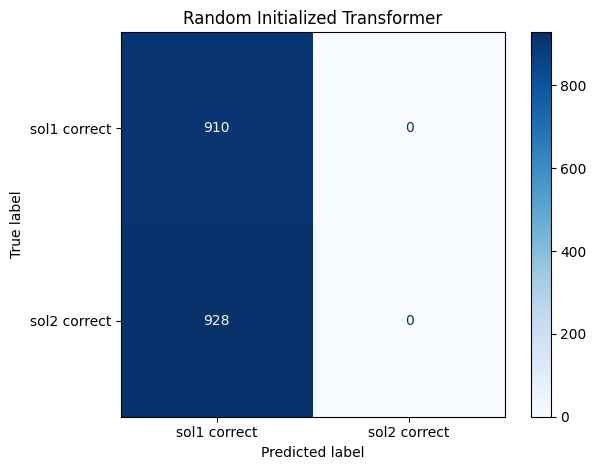

Total errors: 928/1838

First 5 misclassified examples:

Goal:  dresser
Sol1:  replace drawer with bobby pin 
Sol2:  finish, woodgrain with  bobby pin 
True: sol2 | Predicted: sol1

Goal:  To fight Ivan Drago in Rocky for sega master system.
Sol1:  Drago isn't in this game because it was released before Rocky IV.
Sol2:  You have to defeat Apollo Creed and Clubber Lang first.
True: sol2 | Predicted: sol1

Goal:  Make outdoor pillow.
Sol1:  Blow into tin can and tie with rubber band.
Sol2:  Blow into trash bag and tie with rubber band.
True: sol2 | Predicted: sol1

Goal:  Remove soap scum from shower door.
Sol1:  Rub hard with bed sheets, then rinse.
Sol2:  Rub hard with dryer sheets, then rinse.
True: sol2 | Predicted: sol1

Goal:  Recycle a spray bottle for a new cleaner.
Sol1:  Open the top of the empty spray bottle and check for damage. Rinse the bottle then fill halfway with warm water. Replace the spray nozzle and pump a few times to clear the hose. Empty sparrow bottle and allow t

In [30]:
best_model1 = load_best_model(BEST_MODEL1_PATH, get_randomly_initialized_transformer())
predictions1, labels1 = evaluate_transformer(best_model1, test_loader)

plot_confusion_matrix(labels1, predictions1, "Random Initialized Transformer")
print_error_analysis(labels1, predictions1, test_split)
del best_model1

### Pretrained Transformer

With `735` errors the pretrained model makes meaningful predictions for both classes. It performs better on sol1 (`604` correct, `306` wrong) than on sol2 (`499` correct, `429` wrong), indicating a slight bias toward predicting sol1. This is consistent with the overfitting observed during training.

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


              precision    recall  f1-score   support

sol1 correct       0.58      0.66      0.62       910
sol2 correct       0.62      0.54      0.58       928

    accuracy                           0.60      1838
   macro avg       0.60      0.60      0.60      1838
weighted avg       0.60      0.60      0.60      1838


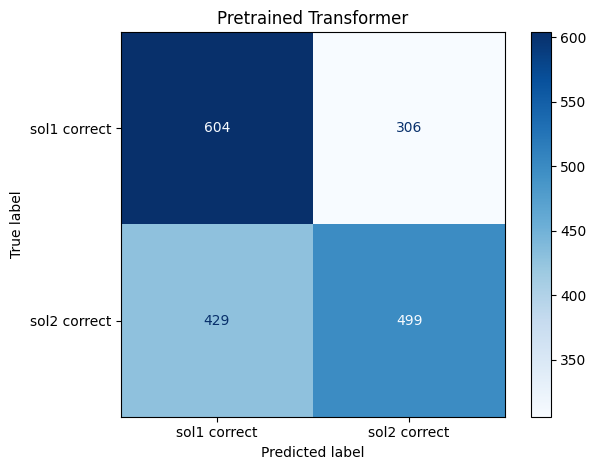

Total errors: 735/1838

First 5 misclassified examples:

Goal:  dresser
Sol1:  replace drawer with bobby pin 
Sol2:  finish, woodgrain with  bobby pin 
True: sol2 | Predicted: sol1

Goal:  To fight Ivan Drago in Rocky for sega master system.
Sol1:  Drago isn't in this game because it was released before Rocky IV.
Sol2:  You have to defeat Apollo Creed and Clubber Lang first.
True: sol2 | Predicted: sol1

Goal:  Make outdoor pillow.
Sol1:  Blow into tin can and tie with rubber band.
Sol2:  Blow into trash bag and tie with rubber band.
True: sol2 | Predicted: sol1

Goal:  Remove soap scum from shower door.
Sol1:  Rub hard with bed sheets, then rinse.
Sol2:  Rub hard with dryer sheets, then rinse.
True: sol2 | Predicted: sol1

Goal:  How to make tissue paper window decorations?
Sol1:  Find tissue paper and fold it in half. Take scissors and cut out pieces of the paper in the middle. When you are done tape it to your window.
Sol2:  Find tissue paper and fold it in half. Take scissors and t

In [31]:
best_model2 = load_best_model(BEST_MODEL2_PATH, get_pretrained_transformer())
predictions2, labels2 = evaluate_transformer(best_model2, test_loader)

plot_confusion_matrix(labels2, predictions2, "Pretrained Transformer")
print_error_analysis(labels2, predictions2, test_split)
del best_model2

### Transformer Results Log

In [32]:
if not SKIP_TRAINING:
    with wandb.init(project=wandb_project, name=f"eval_{TS}"):
        wandb.log({
            f"{MODEL1_NAME}/test_acc": accuracy_score(labels1, predictions1),
            f"{MODEL2_NAME}/test_acc": accuracy_score(labels2, predictions2),
        })
else:
    print("training skipped")

training skipped


### Large Language Model

To evaluate the LLM results all unparsable outputs have to be filtered. The test set accuracy is then logged to W&B.


| Model                 | Prompt                                                       | Test Acc |
|-----------------------|--------------------------------------------------------------|----------|
| Qwen2.5-1.5B-Instruct | 1. Direct user prompt, predict "1" or "2"                    | 0.61     |
| Qwen2.5-1.5B-Instruct | 2. System + user prompt, role assignment, predict "A" or "B" | 0.61     |
| Qwen2.5-3B-Instruct   | 2. System + user prompt, role assignment, predict "A" or "B" | 0.753    |


With `454` errors the LLM achieves the best performance by a large margin. The confusion matrix is well balanced, `618` correct for sol1 and `766` correct for sol2 it shows that it had no systematic bias toward either class.


              precision    recall  f1-score   support

sol1 correct       0.79      0.68      0.73       910
sol2 correct       0.72      0.83      0.77       928

    accuracy                           0.75      1838
   macro avg       0.76      0.75      0.75      1838
weighted avg       0.76      0.75      0.75      1838


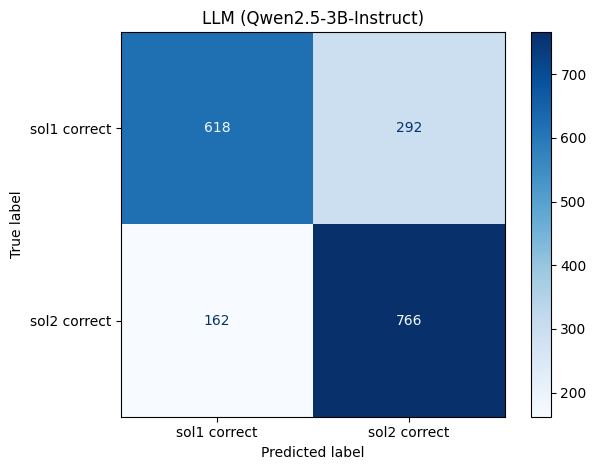

Total errors: 454/1838

First 5 misclassified examples:

Goal:  dresser
Sol1:  replace drawer with bobby pin 
Sol2:  finish, woodgrain with  bobby pin 
True: sol2 | Predicted: sol1

Goal:  To fight Ivan Drago in Rocky for sega master system.
Sol1:  Drago isn't in this game because it was released before Rocky IV.
Sol2:  You have to defeat Apollo Creed and Clubber Lang first.
True: sol2 | Predicted: sol1

Goal:  ice box
Sol1:  will turn into a cooler if you add water to it
Sol2:  will turn into a cooler if you add soda to it
True: sol1 | Predicted: sol2

Goal:  Recycle a spray bottle for a new cleaner.
Sol1:  Open the top of the empty spray bottle and check for damage. Rinse the bottle then fill halfway with warm water. Replace the spray nozzle and pump a few times to clear the hose. Empty sparrow bottle and allow to dry before using with a new cleaner.
Sol2:  Open the top of the empty spray bottle and check for damage. Rinse the bottle then fill halfway with warm water. Replace the spr

In [33]:
if not SKIP_LLM_INFERENCE:
    labels_test_split = [row[COL_LABEL] for row in test_split]
    
    filtered = [(i, true, pred) for i, (true, pred) in enumerate(zip(labels_test_split, llm_predictions)) if pred != -1]
    filtered_indices, filtered_true, filtered_pred = zip(*filtered)
    
    print(classification_report(filtered_true, filtered_pred, target_names=["sol1 correct", "sol2 correct"]))
    plot_confusion_matrix(list(filtered_true), list(filtered_pred), "LLM (Qwen2.5-3B-Instruct)")
    print_error_analysis(list(filtered_true), list(filtered_pred), test_split, n=5, indices=list(filtered_indices))
else:
    print("llm inference skipped")

## Interpretation

Even a lightweight LLM with 1.5B parameters can exceed the performance of a finetuned pretrained and random transformer model slightly. When choosing a bit larger model with 3B the accuracy performs even better and outruns the transformer models by far. 

It is not worth it training a own LLM when such great results on a specific task can be achieved by prompt engineering an open source (apache 2.0 licenced model - all qwen2.5).


The **randomly initialized transformer** never learned anything meaningful, it collapsed to always predicting sol1, achieving baseline accuracy of `0.496`. That this model performs badly is expected. With 110M parameters trained from scratch on 15k examples only it could not develop the language understanding the this PIQA tasks requires. 

The **pretrained transformer** improved to `0.61` confirming that BERT's pretraining on BooksCorpus and English Wikipedia transfers useful language knowledge to PIQA. However the improvement is modest and the model overfit heavily during training because train accuracy reached `0.95` while validation accuracy plateaued around `0.63`. In this case the 15k training examples are not enough for the classifier head to generalize well on top of the pretrained representations.

The **LLM** reached `0.753` outperforming both transformer models by a large margin without any finetuning at all. This shows that scale and broad pretraining data matter far more than task specific fine tuning for physical commonsense reasoning. The error analysis supports this as the LLM handles subtle physical distinctions that the pretrained transformer gets wrong. Its larger training corpus covers a much wider range of everyday physical knowledge.
